<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_13_5_self_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 13: Other Techniques**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 13 Material

* Part 13.1: Autoencoders and Dimensionality Reduction [[Video]]() [[Notebook]](t81_558_class_13_1_auto_encode.ipynb)
* Part 13.2: Anomaly Detection [[Video]]() [[Notebook]](t81_558_class_13_2_anomaly.ipynb)
* Part 13.3: Reinforcement Learning with TorchRL [[Video]]() [[Notebook]](t81_558_class_13_3_reinforcement.ipynb)
* Part 13.4: Pruning Neural Networks [[Video]]() [[Notebook]](t81_558_class_13_4_pruning.ipynb)
* **Part 13.5: Self-Supervised Learning** [[Video]]() [[Notebook]](t81_558_class_13_5_self_supervised.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 13.5: Self-Supervised Learning

Labeled data is expensive. Photographs, medical scans, and audio recordings exist in enormous quantities, but attaching reliable labels to them requires human effort that does not scale. **Self-supervised learning** (SSL) is a strategy for learning useful representations from unlabeled data by inventing a supervisory signal from the data itself. The model is given a *pretext task*, an artificial problem whose answer can be generated automatically, and in solving it the model is forced to learn about the structure of the data. Those learned features can then be transferred to a real *downstream* task using only a small amount of labeled data.

This idea powers many of the largest modern models. Language models are pretrained by predicting masked or next words, a label that comes free with any text. Vision models are pretrained by tasks such as predicting image rotations, filling in missing patches, or, most successfully, *contrastive learning*, which teaches the model that two augmented views of the same image should have similar representations while different images should not. In every case, no human labels are used during pretraining.

This section demonstrates the self-supervised recipe end to end on handwritten digits. We use contrastive learning to train an encoder with no labels at all, teaching it that two randomly augmented views of the same image should land close together in representation space. We then freeze that encoder and evaluate its representations with a *linear probe* trained on only a handful of labeled examples, showing that self-supervised pretraining produces features that make downstream learning far more label-efficient than using the raw pixels or an untrained network.

## Pretext Tasks

The heart of self-supervised learning is designing a pretext task whose labels are free but whose solution requires genuine understanding. A good pretext task cannot be solved by a shortcut; the model must learn something transferable. Several families have proven effective.

* **Predicting transformations.** Rotate each image by a random multiple of 90 degrees and train the model to identify the rotation. To know that a digit has been turned on its side, the model must first learn what the digit normally looks like.
* **Masked prediction.** Hide part of the input and train the model to reconstruct it, the approach behind masked language models and masked-image models.
* **Contrastive learning.** Create two augmented views of each image and train the model to recognize which pairs came from the same original, pulling matching views together in representation space and pushing non-matching ones apart.

We use **contrastive learning**, the most influential of these approaches and the engine behind methods such as SimCLR. For each unlabeled image we create two augmented views by adding noise and randomly masking pixels. The encoder is trained so that the two views of the same image are close together while views of different images are pushed apart. To satisfy this, the encoder must ignore the random corruption and focus on the stable content that identifies each digit, which is exactly the transferable structure we want.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)

digits = load_digits()
X = MinMaxScaler().fit_transform(digits.data).astype(np.float32)
y = digits.target.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_tr_t = torch.tensor(X_tr)
X_te_t = torch.tensor(X_te)


def augment(x):
    """Create a randomly corrupted view: additive noise plus random pixel masking."""
    noisy = x + 0.25 * torch.randn_like(x)
    mask = (torch.rand_like(x) > 0.2).float()      # drop about 20% of pixels
    return (noisy * mask).clamp(0.0, 1.0)


print(f"unlabeled training images: {len(X_tr)}  (digit labels withheld during pretraining)")

unlabeled training images: 1257  (digit labels withheld during pretraining)


## Pretraining with Contrastive Learning

Contrastive learning uses an **encoder** and a small **projection head**. The encoder maps an image to the representation we will keep and transfer; the projection head maps that representation into the space where the contrastive loss is computed, and is thrown away afterward. This two-stage design is standard in modern contrastive methods, because the representation just before the projection turns out to transfer better than the projected vectors themselves.

For each batch of unlabeled images we build two augmented views, encode and project both, and apply the **InfoNCE** loss. For every image, its two views form a *positive pair* that should have high similarity, while every other image in the batch acts as a *negative* that should have low similarity. Similarity is measured by the cosine between the normalized projections, scaled by a temperature. Notice that the encoder's output layer has no activation, so the learned representation is free to take any real values rather than being clamped to be non-negative.

In [3]:
class Encoder(nn.Module):
    def __init__(self, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, embed_dim),            # no activation on the output
        )

    def forward(self, x):
        return self.net(x)


encoder = Encoder()
projection = nn.Sequential(nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 32))

params = list(encoder.parameters()) + list(projection.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)
TEMPERATURE = 0.5

for epoch in range(300):
    batch = X_tr_t[torch.randperm(len(X_tr_t))[:256]]

    # Two augmented views, encoded and projected onto a unit sphere.
    z1 = F.normalize(projection(encoder(augment(batch))), dim=1)
    z2 = F.normalize(projection(encoder(augment(batch))), dim=1)

    # InfoNCE: each view's positive is its counterpart; all others are negatives.
    z = torch.cat([z1, z2], dim=0)
    similarity = z @ z.t() / TEMPERATURE
    b = batch.shape[0]
    targets = torch.cat([torch.arange(b) + b, torch.arange(b)])
    similarity.fill_diagonal_(-9e15)              # a view is never its own positive
    loss = F.cross_entropy(similarity, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 60 == 0 or epoch == 299:
        print(f"epoch {epoch:3d}   contrastive (InfoNCE) loss {loss.item():.3f}")

epoch   0   contrastive (InfoNCE) loss 6.223
epoch  60   contrastive (InfoNCE) loss 5.185
epoch 120   contrastive (InfoNCE) loss 5.132


epoch 180   contrastive (InfoNCE) loss 5.070
epoch 240   contrastive (InfoNCE) loss 5.024
epoch 299   contrastive (InfoNCE) loss 5.007


## Evaluating with a Linear Probe

The standard way to measure the quality of self-supervised features is the **linear probe**: freeze the encoder and train only a single linear layer on top of its representations to solve the real task, here classifying the ten digits. If a simple linear classifier can read digit identity off the frozen features, then the encoder must have organized the data well during pretraining. We train the probe on only a small labeled sample to test *label efficiency*, the whole promise of self-supervision.

To judge whether pretraining actually helped, we compare three approaches, all given the same small labeled set: a linear classifier on the frozen contrastive features, a linear classifier on the raw pixels, and a linear classifier on the features of a randomly initialized, untrained encoder. That last one is the crucial control. Because it shares the contrastive encoder's exact architecture, any gap between the two must come from the self-supervised pretraining rather than from the network structure.

In [4]:
def linear_probe(features_tr, labels_tr, features_te, labels_te, epochs=300):
    clf = nn.Linear(features_tr.shape[1], 10)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-2)
    loss_fn = nn.CrossEntropyLoss()
    Xtr, ytr = torch.tensor(features_tr), torch.tensor(labels_tr)
    for _ in range(epochs):
        opt.zero_grad()
        loss_fn(clf(Xtr), ytr).backward()
        opt.step()
    with torch.no_grad():
        pred = clf(torch.tensor(features_te)).argmax(1).numpy()
    return (pred == labels_te).mean()


# Use only a small labeled subset for the downstream task.
N_LABELS = 50
idx = np.random.RandomState(0).permutation(len(X_tr))[:N_LABELS]
X_lab, y_lab = X_tr[idx], y_tr[idx]

# Encode the data with the pretrained encoder and with a random one.
random_encoder = Encoder()                        # same architecture, never trained
with torch.no_grad():
    f_ssl_tr = encoder(torch.tensor(X_lab)).numpy()
    f_ssl_te = encoder(X_te_t).numpy()
    f_rnd_tr = random_encoder(torch.tensor(X_lab)).numpy()
    f_rnd_te = random_encoder(X_te_t).numpy()

acc_ssl = linear_probe(f_ssl_tr, y_lab, f_ssl_te, y_te)
acc_raw = linear_probe(X_lab,    y_lab, X_te,    y_te)
acc_rnd = linear_probe(f_rnd_tr, y_lab, f_rnd_te, y_te)

print(f"With only {N_LABELS} labeled examples, digit-classification test accuracy:")
print(f"  contrastive self-supervised features: {acc_ssl:.3f}")
print(f"  raw pixels (no encoder):              {acc_raw:.3f}")
print(f"  random untrained encoder (control):   {acc_rnd:.3f}")

With only 50 labeled examples, digit-classification test accuracy:
  contrastive self-supervised features: 0.839
  raw pixels (no encoder):              0.831
  random untrained encoder (control):   0.600


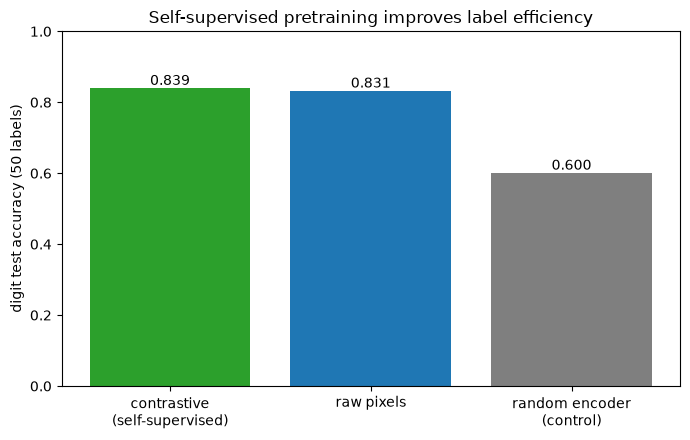

In [5]:
plt.figure(figsize=(7, 4.5))
bars = ["contrastive\n(self-supervised)", "raw pixels", "random encoder\n(control)"]
vals = [acc_ssl, acc_raw, acc_rnd]
colors = ["tab:green", "tab:blue", "tab:gray"]
plt.bar(bars, vals, color=colors)
plt.ylabel(f"digit test accuracy ({N_LABELS} labels)")
plt.title("Self-supervised pretraining improves label efficiency")
for i, v in enumerate(vals):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The comparison against the random encoder is the decisive one: the two networks share an identical architecture, so the large gap between them can only come from the self-supervised pretraining. Contrastive learning, using no labels whatsoever, produced an encoder whose features let a linear classifier separate digits far better than the untrained encoder's features do. The contrastive representation also holds its own against the raw-pixel baseline, which is unusually strong here because these small digit images are already nearly linearly separable; on the high-dimensional, tangled data where deep learning is genuinely needed, learned representations pull ahead of raw inputs by a wide margin.

This label efficiency is why self-supervised learning has become central to modern deep learning. Pretrain once on a large unlabeled corpus, then adapt to many downstream tasks with only a little labeled data. The contrastive task here is deliberately small, but the recipe, invent a label-free pretext task, pretrain an encoder, and transfer its features, is exactly the one behind today's large language and vision foundation models.

This concludes Module 13. Across these sections we have seen techniques that fall outside the standard supervised-classification mold: autoencoders that compress data without labels, anomaly detectors built from reconstruction error, agents that learn from reward through reinforcement learning, pruning that shrinks trained networks, and self-supervised learning that turns unlabeled data into useful representations. Each extends the deep-learning toolkit into a different practical setting.